### Import Libraries

In [1]:
# pandas -> used to read dataset and handle tables (DataFrame)
import pandas as pd

# numpy -> used for mathematical operations (arrays, sqrt, etc.)
import numpy as np

# matplotlib -> used to visualize the relationship between variables
import matplotlib.pyplot as plt

# makes plots appear inside jupyter notebook
%matplotlib inline

### Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\ANKIT\Downloads\weight_height_noisy.csv")
df.head()

,Weight,Height
0,41.0,140
1,40.0,142
2,44.1,145
3,50.3,147
4,41.1,150


### Visualize the Data

Text(0.5, 1.0, 'Weight vs Height Relationship')

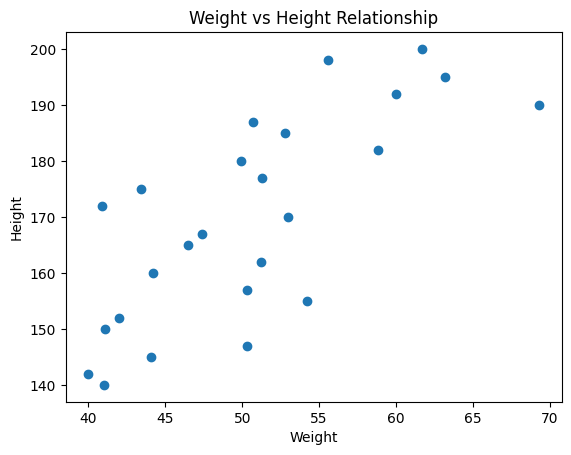

In [3]:
# scatter plot to see relationship between weight and height
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Weight vs Height Relationship")

### Separate Features and Target

In [4]:
## Dividing Features into Independent and Dependent Fetaures
X = df[['Weight']] ## Independent features should be dataframe or 2 dimensional array
y = df['Height'] ## This variable can be in series or 1d array

In [5]:
X_series = df['Weight'] ## This practice we should avoid
np.array(X_series).shape

(25,)

In [6]:
X.head().shape

(5, 1)

In [7]:
y.head().shape

(5,)

### Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

# 75% training, 25% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# learn mean & std from training data and scale it
X_train = scaler.fit_transform(X_train)

# apply SAME scaling to test data
X_test = scaler.transform(X_test)


fit_transform(X_train)

    calculates mean & standard deviation

    then scales training data

    transform(X_test)

    uses SAME training mean & std

    prevents data leakage

If we use fit_transform(X_test):
model secretly learns about test data → evaluation becomes fake.

### Train Linear Regression Model

In [10]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

# model learns relationship between X and y
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Reason:
Here model calculates the equation:

    Height=m(Weight)+c

    coef_ → slope (m)

    intercept_ → bias (c)

### View Model Parameters

In [11]:
print('Slope or Coefficient : ',regression.coef_)
print('Intercept : ',regression.intercept_)

Slope or Coefficient :  [14.49009398]
Intercept :  170.33333333333337


### Plot Training Data Plot best fit line

Text(0.5, 1.0, 'Best Fit Line')

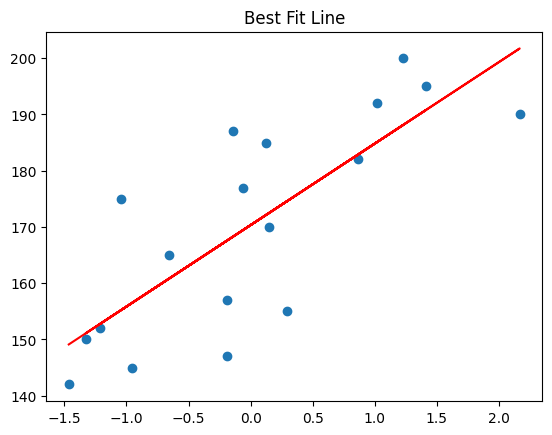

In [12]:
# training data points
plt.scatter(X_train[:,0], y_train)

# regression line
plt.plot(X_train[:,0], regression.predict(X_train), color='red')
plt.title("Best Fit Line")


## Prediction on Test Data

In [13]:
y_pred = regression.predict(X_test)

## Model Evaluation

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 11.618070927430523
MSE : 180.4898684037962
RMSE: 13.43465177828574
R2 Score: 0.3499923892557685


## Statsmodels

In [15]:
import statsmodels.api as sm

# statsmodels needs constant (bias column)
X_train_sm = sm.add_constant(X_train)

model = sm.OLS(y_train, X_train_sm).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                 Height   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.583
Method:                 Least Squares   F-statistic:                     24.78
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           0.000137
Time:                        10:48:39   Log-Likelihood:                -69.728
No. Observations:                  18   AIC:                             143.5
Df Residuals:                      16   BIC:                             145.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        170.3333      2.911     58.512      0.0

### Prediction for new weight

In [16]:
# always scale new input using same scaler
new_weight = scaler.transform([[60]])

predicted_height = regression.predict(new_weight)
print("Predicted height for 60kg person:", predicted_height)


Predicted height for 60kg person: [185.02644176]


C:\Users\ANKIT\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
